# Libraries

In [ ]:
%%capture
!pip install kaggle
!pip install folium
!pip install feature_engine
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import folium
import kagglehub
import seaborn as sns
from folium.plugins import HeatMap
from collections import Counter
import textwrap

from feature_engine.encoding import OrdinalEncoder, OneHotEncoder
from feature_engine.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN

from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score, silhouette_score, precision_recall_curve, auc, average_precision_score, roc_curve, silhouette_samples, precision_score, recall_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import xgboost as xgb
from xgboost import XGBClassifier
import shap
import math

import plotly.express as px
from sklearn.manifold import TSNE
from scipy.stats import skew, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import random
import os

sns.set_style('whitegrid')
np.__version__

'2.0.2'

In [ ]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")

In [ ]:
# Set a global seed so work is reproducable with same results
seed = 18 # was 52 before
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# First insights

In [ ]:
df = pd.read_csv(f'{path}/fraudTrain.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [ ]:
(len(df[df['is_fraud'] == 1]) / len(df)) * 100

0.5788651743883394

In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df[df.duplicated()] # No duplicated rows

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [ ]:
df.isna().sum() # No null values

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


# Data Analysis & Visualization

## Preprocessing

In [ ]:
# Convert features to their suitable type, preprocess features, and feature engineering for aid in visualization
def feature_analysis_preprocessing(df):

  # Remove fraud_ tag from all merchants
  df['merchant'] = df['merchant'].apply(lambda item : item.replace('fraud_', ''))

  # Convert time-related objects to their correct type (datetime object)
  df['dob'] = pd.to_datetime(df['dob'])
  df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

  # Feature engineering
  #current_year = pd.Timestamp.now().year # Obtain current year
  df['age'] = 2021 - df['dob'].dt.year # Extract age of user

  age_bins = [16, 30, 50, 65, 101] # Group ages into bins
  age_label = ['Young Adult', 'Middle Aged', 'Adult', 'Senior'] # Label for each bin
  df['age_group'] = pd.cut(df['age'], bins = age_bins, labels = age_label, include_lowest = True) # Bin ages to labels (e.g, age 0-18 to young adult, 19-30 to middle aged, etc...)

  # Extract year, month, day, hour, minute of transaction
  df['year'] = df['trans_date_trans_time'].dt.year
  df['month'] = df['trans_date_trans_time'].dt.month
  df['day'] = df['trans_date_trans_time'].dt.day
  df['hour'] = df['trans_date_trans_time'].dt.hour
  df['minute'] = df['trans_date_trans_time'].dt.minute

  # Map related categories to one bin
  df['category'] = df['category'].map({'gas_transport':'gas_transport',
                                                'home': 'home',
                                                'shopping_pos':'shopping',
                                                'shopping_net':'shopping',
                                                'kids_pets':'kids_pets',
                                                'entertainment':'entertainment',
                                                'food_dining':'food_dining',
                                                'personal_care':'personal_care',
                                                'health_fitness':'health_fitness',
                                                'misc_pos':'misc',
                                                'misc_net':'misc',
                                                'grocery_net':'grocery',
                                                'grocery_pos':'grocery',
                                                'travel':'travel'})

  return df

df = feature_analysis_preprocessing(df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 30 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    12966

## Merchant Feature

In [ ]:
len(df['merchant'].unique()), len(df['merchant'])

(693, 1296675)

In [ ]:
merch_count = Counter(df['merchant']) # Count number of occurence per merchant
merch_count = dict(sorted(merch_count.items(), key = lambda item: item[1], reverse = True)) # key -> sorting by (item[1] is value) in dictionary (key, value)

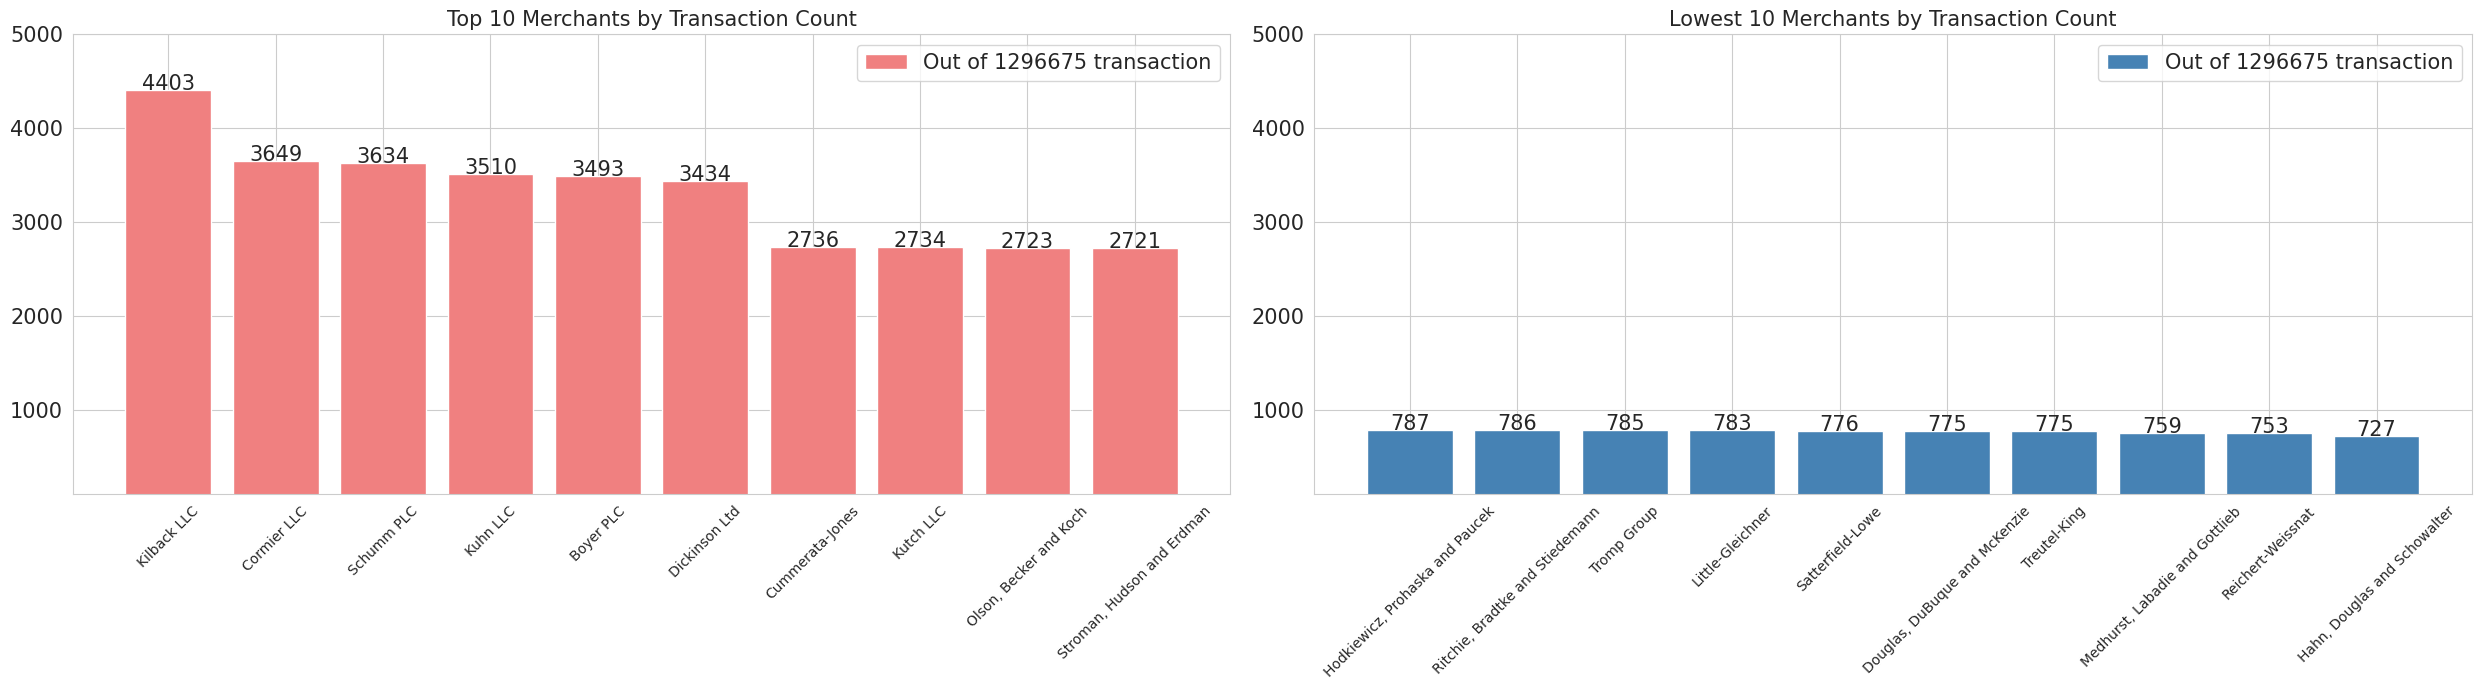

In [ ]:
top = 10
top_merchants_keys = list(merch_count.keys())[:top]
low_merchants_keys = list(merch_count.keys())[-top:]

top_values = [merch_count[t] for t in top_merchants_keys]
low_values = [merch_count[l] for l in low_merchants_keys]

legend_label = f'Out of {sum(merch_count.values())} transaction'

plt.figure(figsize = (25, 7))

# Top Merchants
plt.subplot(1, 2, 1)
plt.bar(top_merchants_keys, top_values, color = 'lightcoral', label = legend_label)

for i, value in enumerate(top_values):
  plt.text(i, value, str(int(value)), ha = 'center', fontsize = 15)

plt.title('Top 10 Merchants by Transaction Count', fontsize = 15)
plt.xticks(fontsize = 10, rotation = 45)
plt.yticks(fontsize = 15)
plt.ylim((100, 5000))
plt.legend(fontsize = 15)

# Low Merchants
plt.subplot(1, 2, 2)
plt.bar(low_merchants_keys, low_values, color = 'steelblue', label = legend_label)

for i, value in enumerate(low_values):
  plt.text(i, value, str(int(value)), ha = 'center', fontsize = 15)

plt.title('Lowest 10 Merchants by Transaction Count', fontsize = 15)
plt.xticks(fontsize = 10, rotation = 45)
plt.yticks(fontsize = 15)
plt.ylim((100, 5000))
plt.legend(fontsize = 15)

plt.tight_layout()
plt.show()

## Feature Category

In [ ]:
len(df['category']), len(df['category'].unique())

(1296675, 11)

In [ ]:
category_count = Counter(df['category']) # Count number of occurence per category
total = sum(category_count.values()) # Total number of categories
category_percent = {key: round((value / total) * 100, 2) for key, value in category_count.items()} # Convert to percentage %

category_percent = dict(sorted(category_percent.items(), key = lambda item: item[1], reverse = False)) # key -> sorting by (item[1] is value) in dictionary (key, value)

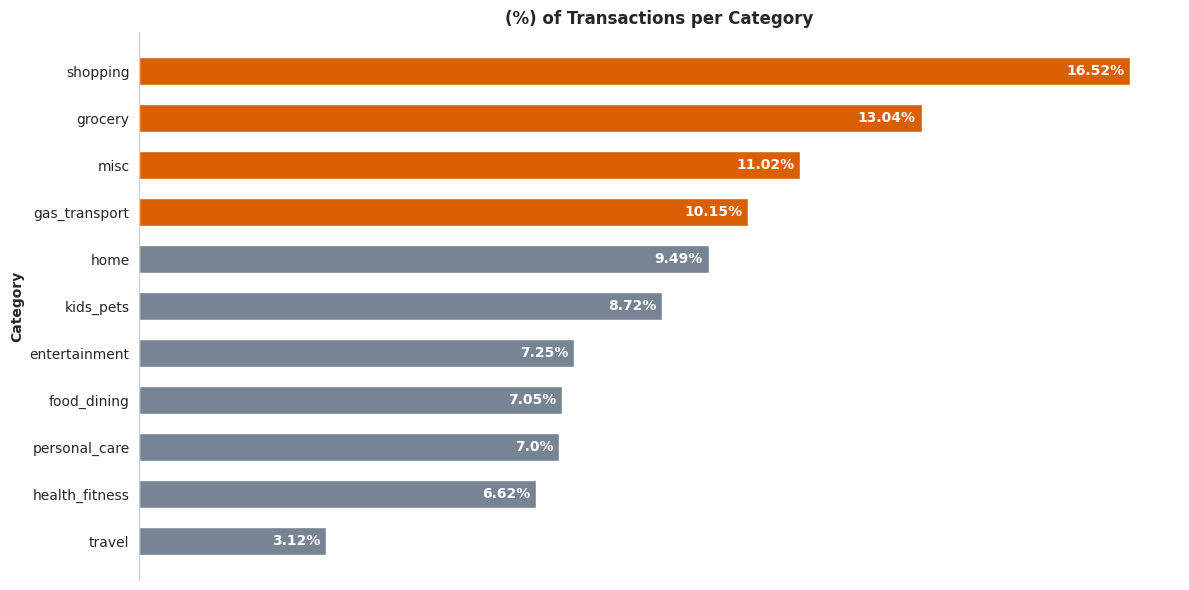

In [ ]:
plt.figure(figsize = (12, 6))
highlight_color = '#d95f02'
other_color = '#768493'
top_values = list(category_percent.values())[-4] # Obtain top 4 features

for i, c in enumerate(category_percent):
  name, value = c, category_percent[c]
  plt.barh(name, value, color = (highlight_color if value >= top_values else other_color), height = 0.6)
  plt.text(value - 0.1, name, str(value) + '%', ha = 'right', va = 'center', fontsize = 10, fontweight = 'bold', color = 'white')

plt.title('(%) of Transactions per Category', fontweight = 'bold')
plt.ylabel('Category', fontweight = 'bold')
plt.grid(False)
plt.xticks([])

for spine in ['right', 'top', 'bottom']: # Despine axes
  plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Age
This feature has been extracted by utilizing the DOB of the user; extract the age of the person, may be helpful in determining severity of fraud transaction

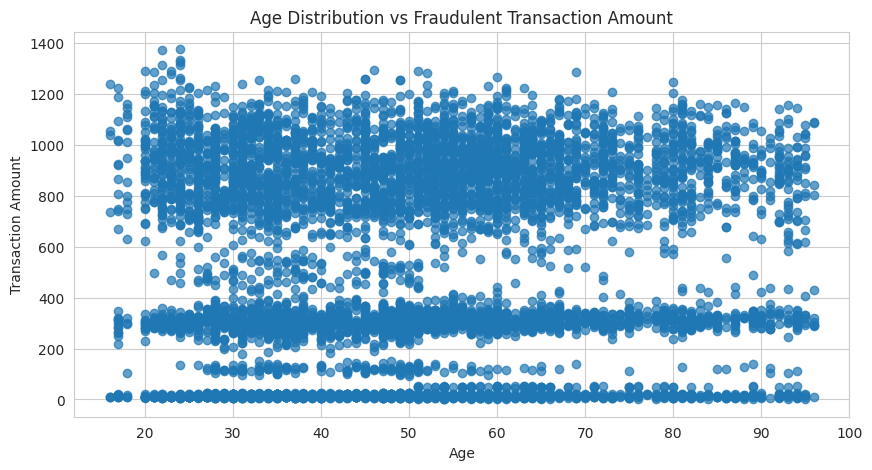

In [ ]:
plt.figure(figsize = (10, 5))
fraud_ds = df[df['is_fraud'] == 1]

plt.scatter(fraud_ds['age'], fraud_ds['amt'], alpha = 0.7, )
plt.title('Age Distribution vs Fraudulent Transaction Amount')
plt.xlabel('Age')
plt.ylabel('Transaction Amount')
plt.grid(True)

plt.show()

In [ ]:
fraud_age = df.groupby('age_group')['is_fraud']

<ipython-input-76-30ac5cd3fdde>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_age = df.groupby('age_group')['is_fraud']


In [ ]:
fraud_sum = fraud_age.sum()
fraud_count = fraud_age.count()

fraud_rate = (fraud_sum / fraud_count) * 100

In [ ]:
fraud_rate = fraud_rate.reset_index()
fraud_rate.columns = ['Age Group', 'Rate']

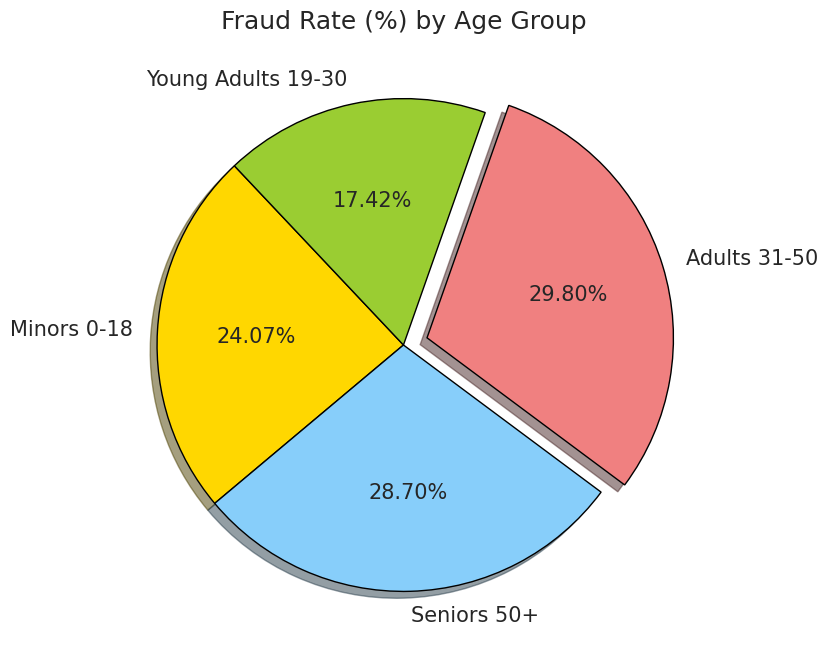

In [ ]:
plt.figure(figsize = (8, 8))
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = [0, 0, 0.1, 0]
labels = ['Minors 0-18', 'Young Adults 19-30', 'Adults 31-50', 'Seniors 50+']

plt.pie(fraud_rate['Rate'],
        labels = labels,
        explode = explode,
        autopct = '%0.2f%%',
        colors = colors,
        shadow = True,
        startangle = 220,
        counterclock=False,
        wedgeprops = {'linewidth': 1, 'edgecolor': 'black'},
        textprops = {'fontsize': 15})

plt.title('Fraud Rate (%) by Age Group', fontsize = 18)
plt.show()

## Date Time Analysis

In [ ]:
trend = df[df['is_fraud'] == 1].groupby(df['trans_date_trans_time'].dt.date)['is_fraud'].count()

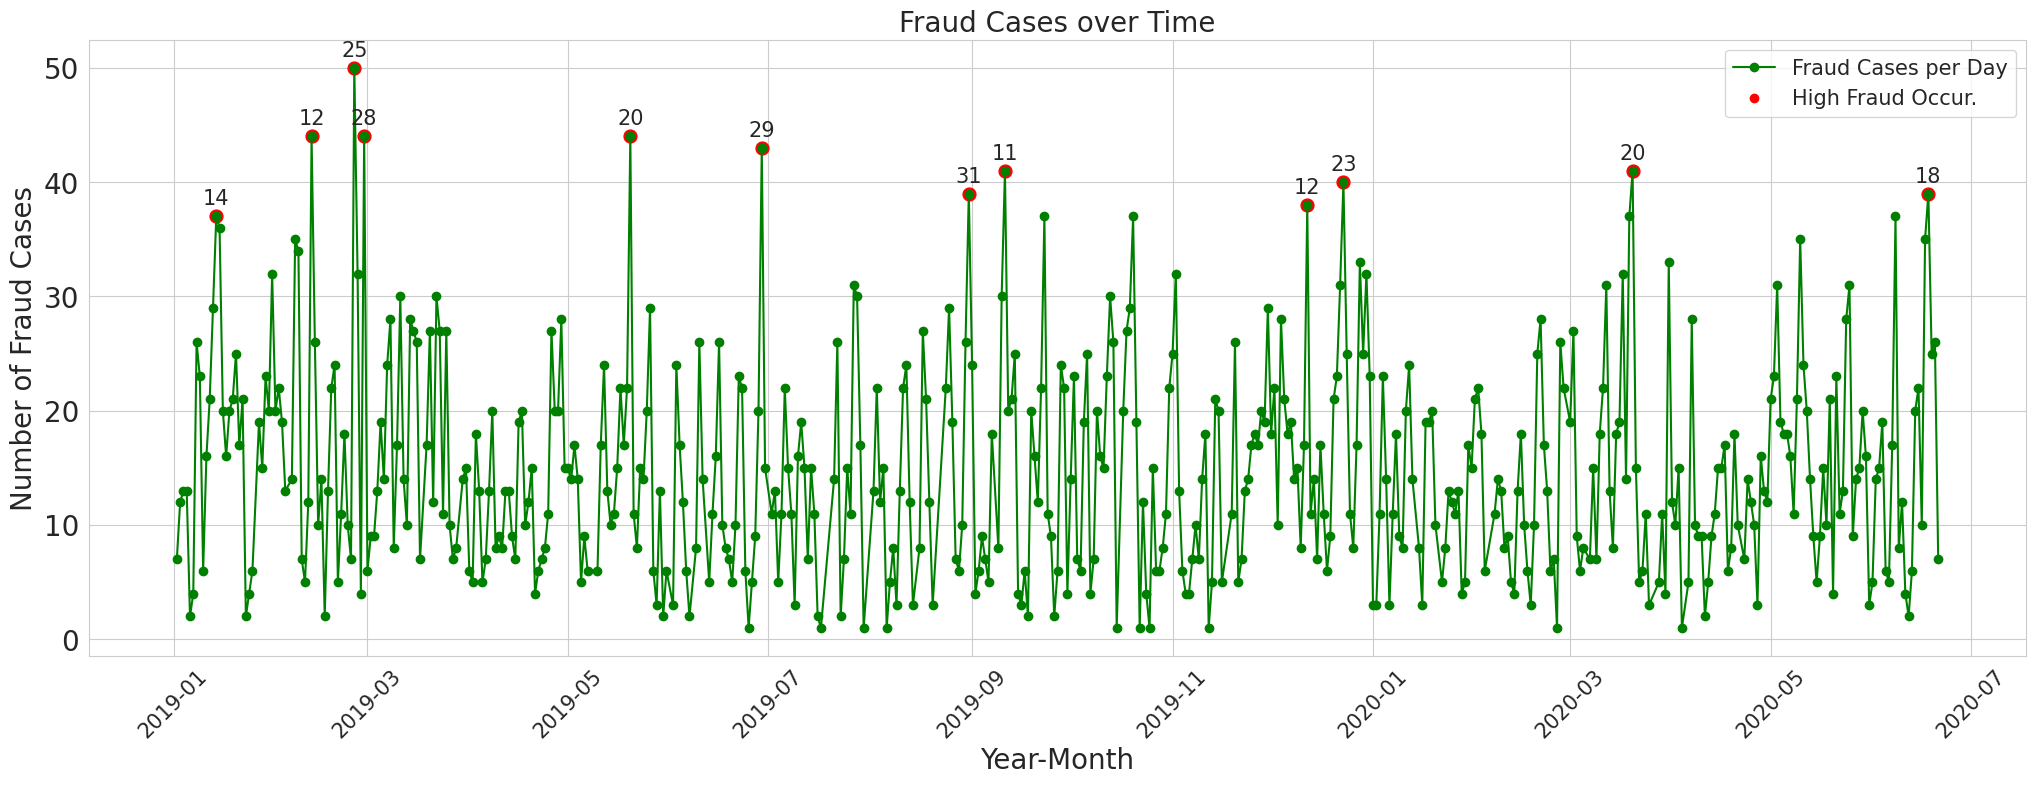

In [ ]:
plt.figure(figsize = (25, 8))
top_12 = trend.nlargest(12).index

plt.plot(trend.index, trend.values, marker = 'o', color = 'green')
plt.scatter(top_12, trend[top_12], color = 'red', s = 85, marker = 'o', alpha = 1)

for date in top_12:
  plt.text(date, trend[date] + 1, f'{date.day}', ha = 'center', fontsize = 15)

plt.title('Fraud Cases over Time', fontsize = 20)
plt.xlabel('Year-Month', fontsize = 20)
plt.ylabel('Number of Fraud Cases', fontsize = 20)
plt.xticks(rotation = 45, fontsize = 15)
plt.yticks(fontsize = 20)
plt.grid(True)

legend_elements = [
  Line2D([0], [0], color = 'green', marker = 'o', label = 'Fraud Cases per Day'),
  Line2D([0], [0], marker = 'o', color = 'red', linestyle = 'None', label = 'High Fraud Occur.'),
]
plt.legend(handles = legend_elements, loc = 'upper right', fontsize = 15)

plt.show()

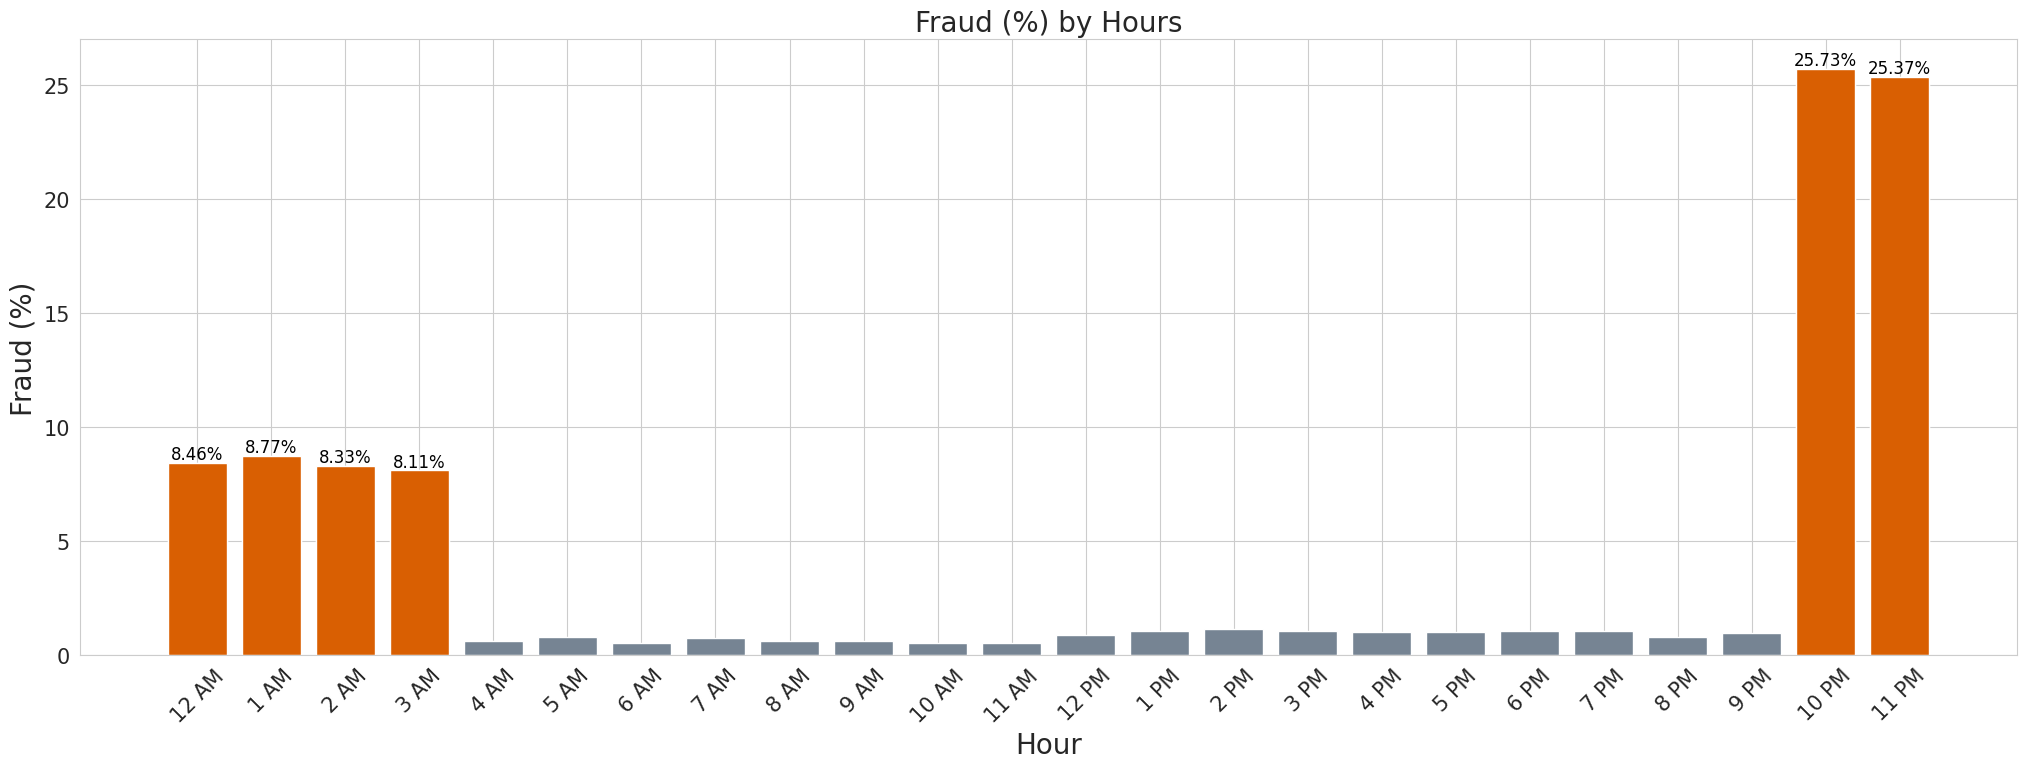

In [ ]:
hour_trend = df[df['is_fraud'] == 1].groupby(df['hour'])['is_fraud'].count()
hour_trend_total = hour_trend.sum()
hour_trend = (hour_trend / hour_trend_total) * 100

top_hours = hour_trend.nlargest(6).index
hour_labels = [f"{(h % 12 or 12)} {'AM' if h < 12 else 'PM'}" for h in range(24)] # 24 hour format -> 12 hour format
bar_width = 0.8

plt.figure(figsize = (25, 8))
plt.bar(hour_trend.index, hour_trend.values, color = other_color, width = bar_width)
plt.bar(top_hours, hour_trend[top_hours], color = highlight_color, width = bar_width)

for h in top_hours:
  plt.text(h, hour_trend[h] + 0.15, f'{hour_trend[h]:.2f}%', ha = 'center', fontsize = 12, color = 'black')

plt.title('Fraud (%) by Hours', fontsize = 20)
plt.xlabel('Hour', fontsize = 20)
plt.ylabel('Fraud (%)', fontsize = 20)
plt.xticks(range(0, 24), hour_labels, rotation = 45, fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)
plt.show()

# Numerical Features

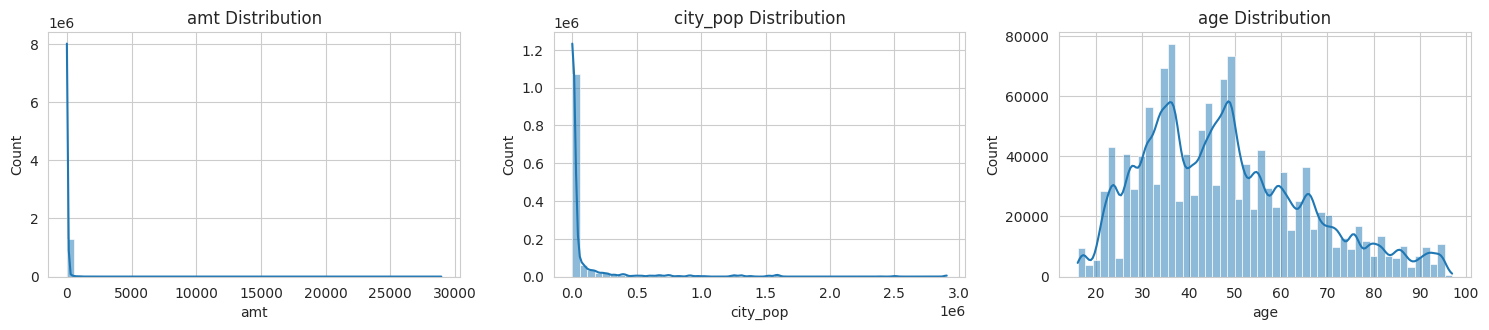

In [ ]:
numeric_features = ['amt', 'city_pop', 'age']

plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_features, 1):
  plt.subplot(2, 3, i)
  sns.histplot(df[col], kde = True, bins = 50) # Show the distribution for each feature
  plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [ ]:
for col in numeric_features:
  sk = skew(df[col].dropna())
  print(f'Skewness of {col}: {sk}') # Display exact skewness percentage

Skewness of amt: 42.2778248827837
Skewness of city_pop: 5.59384659584336
Skewness of age: 0.6123577449233438


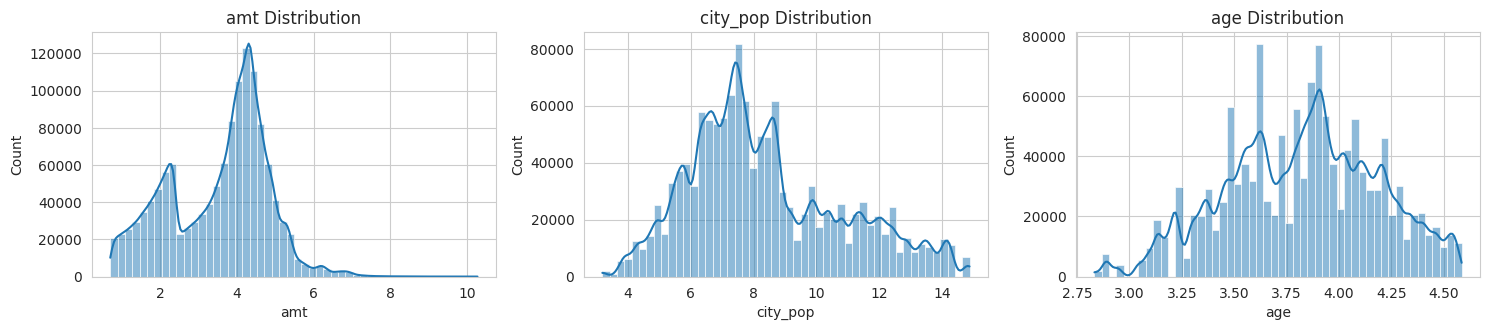

In [ ]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(np.log1p(df[col]), kde = True, bins = 50) # log-transform amt and city_pop
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

## Geolocation information

In [ ]:
map = folium.Map(location = df[['lat', 'long']].to_numpy()[5], zoom_control = 1000)
log_lat = np.unique(df[['lat', 'long']].to_numpy(), axis = 0)

In [ ]:
HeatMap(log_lat).add_to(map)
map

# Feature Preprocessing

In [ ]:
def model_feature_preprocessing(df):
  # Removed 'city'
  df = df[['merchant', 'category', 'amt', 'gender', 'city_pop', 'job', 'is_fraud', 'age', 'year', 'month', 'day', 'hour', 'minute']]

  # Encode Categorical features
  pipe = Pipeline([ # ('ordinal_encoder', OrdinalEncoder(encoding_method = 'arbitrary', variables = ['merchant', 'job', 'city']))
                 ('onehot_encoder', OneHotEncoder(variables = ['category'])),
                 ('label_encoder', OneHotEncoder(variables = ['gender'], drop_last = True))])
  pipe.fit(df)

  transformed_df = pipe.transform(df)
  X = transformed_df.drop('is_fraud', axis = 1)
  y = transformed_df['is_fraud']

  # Frequency-Encode 'merchant' and 'job' (City has been dropped)
  categorical_cols = ['merchant', 'job']

  for col in categorical_cols:
    freq_map = X[col].value_counts().to_dict()
    X[f'{col}_freq'] = X[col].map(freq_map)

  #X = X.drop(categorical_cols, axis = 1)

  # Log-transform skewed features to a Gaussian distribution
  log_cols = ['amt', 'city_pop', 'age'] # added age back to test
  for col in log_cols:
    X[col] = np.log1p(X[col])  # log(1 + x) to avoid zero logs

  # Scale all numerical features
  scale_cols = log_cols + ['year'] +  [f'{col}_freq' for col in categorical_cols]
  scaler = MinMaxScaler()
  X[scale_cols] = scaler.fit_transform(X[scale_cols])

  return df, X, y, scaler

In [ ]:
df, X, y, scaler = model_feature_preprocessing(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = seed)

In [ ]:
# Calculate merchant_risk feature
train_data = X_train.copy()
train_data['is_fraud'] = y_train

alpha = 10 # Smoothing term (Laplacian implementation)
global_fraud_rate = y_train.mean()

merchant_stats = train_data.groupby('merchant')['is_fraud'].agg(['mean', 'count']) # Obtain mean and frequency of fraudelent merchants

# risk_smoothed = mean * freq + all_rate*alpha / (freq + alpha)
merchant_stats['smoothed_risk'] = ((merchant_stats['mean'] * merchant_stats['count'] + global_fraud_rate * alpha) / (merchant_stats['count'] + alpha))

merchant_risk_dict = merchant_stats['smoothed_risk'].to_dict()

X_train['merchant_risk'] = X_train['merchant'].map(merchant_risk_dict)
X_test['merchant_risk'] = X_test['merchant'].map(merchant_risk_dict)

X_test['merchant_risk'].fillna(global_fraud_rate, inplace=True)

<ipython-input-90-e19eeb1b0935>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['merchant_risk'].fillna(global_fraud_rate, inplace=True)


In [ ]:
X_train = X_train.drop(['merchant', 'job'], axis = 1)
X_test = X_test.drop(['merchant', 'job'], axis = 1)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(907672, 389003, 907672, 389003)

In [ ]:
ros = RandomOverSampler(random_state = 42) # Keep random state to 42 for reproducability
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Models

## Classifier: XGBoost

In [ ]:
neg, pos = np.bincount(y_train) # get number of frauds and non-frauds from training set
weight = neg / pos
estimators = 500
lr = 0.2
objective = 'binary:logistic'
metric = 'logloss'

print(neg, pos)
print(weight)

902418 5254
171.75827940616674


In [ ]:
model_base = XGBClassifier(
    n_estimators = estimators,
    learning_rate = lr,
    objective = objective,
    eval_metric = metric,
    random_state = seed)

model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

In [ ]:
print(f'Classification Report:\n {classification_report(y_test, y_pred_base)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_pred_base)}')

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.96      0.85      0.90      2252

    accuracy                           1.00    389003
   macro avg       0.98      0.92      0.95    389003
weighted avg       1.00      1.00      1.00    389003

Confusion Matrix:
 [[386679     72]
 [   349   1903]]


In [ ]:
model_ov = XGBClassifier(
    n_estimators = estimators,
    learning_rate = lr,
    objective = objective,
    eval_metric = metric,
    random_state = seed)

model_ov.fit(X_train_resampled, y_train_resampled)
y_pred_ov = model_ov.predict(X_test)

In [ ]:
print(f'Classification Report:\n {classification_report(y_test, y_pred_ov)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_pred_ov)}')

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.86      0.89      0.88      2252

    accuracy                           1.00    389003
   macro avg       0.93      0.95      0.94    389003
weighted avg       1.00      1.00      1.00    389003

Confusion Matrix:
 [[386422    329]
 [   239   2013]]


In [ ]:
model_weight = XGBClassifier(
    n_estimators = estimators,
    learning_rate = lr,
    objective = objective,
    eval_metric = metric,
    random_state = seed,
    scale_pos_weight = weight)

model_weight.fit(X_train, y_train)
y_pred_weight = model_weight.predict(X_test)

In [ ]:
print(f'Classification Report:\n {classification_report(y_test, y_pred_weight)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_pred_weight)}')

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.84      0.89      0.86      2252

    accuracy                           1.00    389003
   macro avg       0.92      0.94      0.93    389003
weighted avg       1.00      1.00      1.00    389003

Confusion Matrix:
 [[386373    378]
 [   248   2004]]


# XGBoost Interpretation

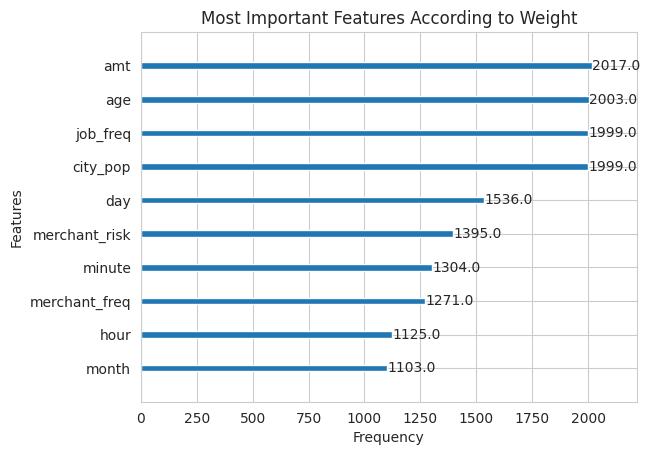

In [ ]:
xgb.plot_importance(model_base, importance_type = 'weight', max_num_features = 10, xlabel = 'Frequency')
plt.title("Most Important Features According to Weight")
plt.show()

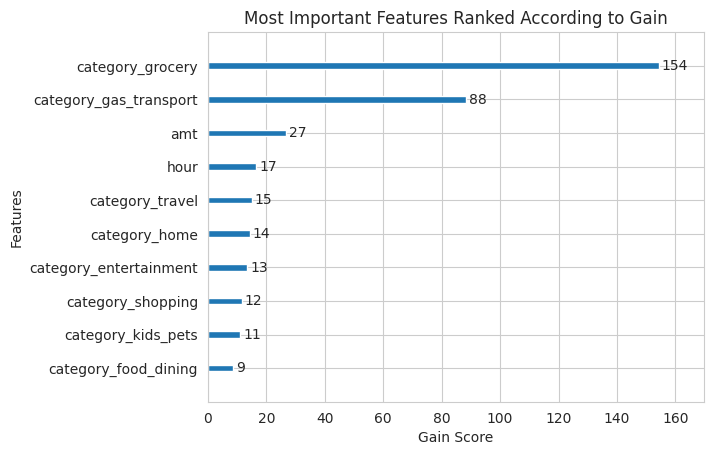

In [ ]:
xgb.plot_importance(model_base, importance_type = 'gain', max_num_features = 10, values_format = '{v:.0f}', xlabel = 'Gain Score')
plt.title("Most Important Features Ranked According to Gain")
plt.show()

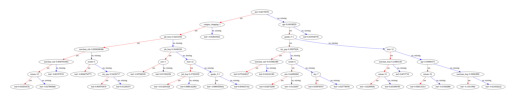

In [ ]:
xgb.plot_tree(model_base, num_trees = 497)
plt.savefig('xgb_tree.png', dpi = 800)

In [ ]:
y_proba = model_base.predict_proba(X_test)[:, 1] # Obtain all fraud
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

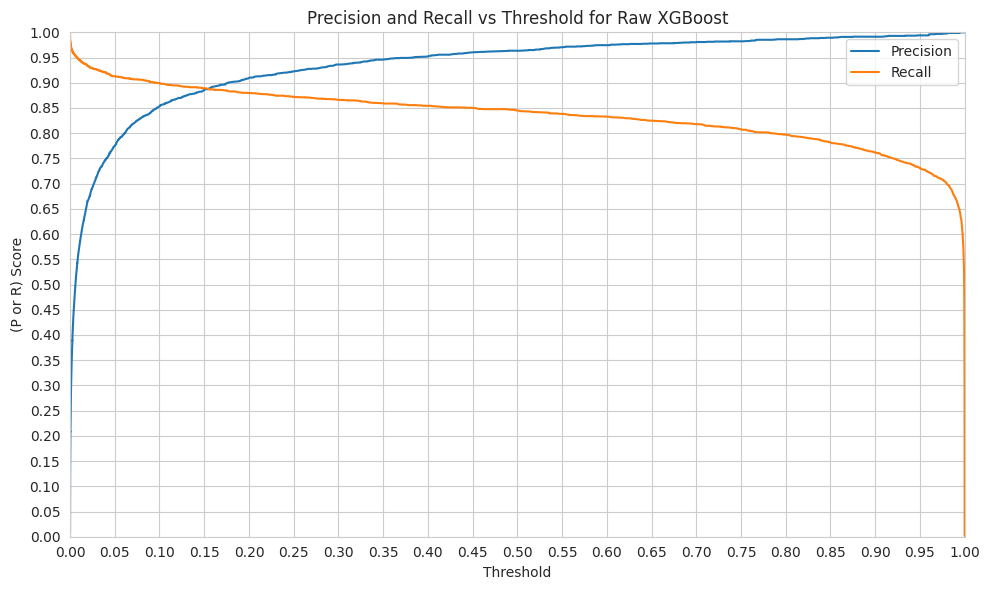

In [ ]:
# Visualize P & R vs Threshold

plt.figure(figsize = (10, 6))
plt.plot(thresholds, precision[:-1], label = 'Precision')
plt.plot(thresholds, recall[:-1], label = 'Recall')
plt.xlabel('Threshold')
plt.ylabel('(P or R) Score')
plt.title('Precision and Recall vs Threshold for Raw XGBoost')
plt.legend(loc = 'best')

# Zoom settings
plt.xlim(0.0, 1.0)
plt.xticks(np.arange(0.0, 1.05, 0.05))

plt.ylim(0.0, 1.0)
plt.yticks(np.arange(0.0, 1.05, 0.05))

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.16
y_pred_T = (y_proba >= threshold).astype(int)

print(f'Classification Report (T = {threshold})')
print(classification_report(y_test, y_pred_T))

print(f'Confusion Matrix with (T = {threshold})')
print(confusion_matrix(y_test, y_pred_T))

Classification Report (T = 0.16)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.89      0.89      0.89      2252

    accuracy                           1.00    389003
   macro avg       0.95      0.94      0.94    389003
weighted avg       1.00      1.00      1.00    389003

Confusion Matrix with (T = 0.16)
[[386510    241]
 [   255   1997]]


## SHAP Analysis

In [ ]:
# #40 minutes run time
# explainer = shap.Explainer(model_base)
# values = explainer(X_test)

# shap.summary_plot(values, X_test)

# Clustering: K-Means

In [ ]:
fraud_mask = (y_pred_T == 1)
fraud_data = X_test[fraud_mask].copy()

In [ ]:
# Select risky features
risk_features = ['amt', 'hour', 'age', 'city_pop', 'job_freq']
X_cluster = fraud_data[risk_features]

# Divide data based on risky features into three distinct risk-levels
cluster = KMeans(n_clusters = 3, random_state = seed)
risk_cluster_labels = cluster.fit_predict(X_cluster)

fraud_data['risk_cluster'] = risk_cluster_labels

score = silhouette_score(X_cluster, risk_cluster_labels) # Log-transforming age increases this score!
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.830


In [ ]:
# Compute mean values of features per cluster
cluster_stats = fraud_data.groupby('risk_cluster')[risk_features].mean()

normalized_stats = (cluster_stats - cluster_stats.mean()) / cluster_stats.std()
risk_scores = normalized_stats.mean(axis = 1)

# Sort clusters by risk score (lowest to highest)
sorted_clusters = risk_scores.sort_values().index.tolist()

In [ ]:
print(sorted_clusters)
risk_scores

[0, 2, 1]


,0
risk_cluster,
0,-0.310419
1,0.260223
2,0.050196


In [ ]:
risk_map = {
  sorted_clusters[0]: 'low-risk',
  sorted_clusters[1]: 'medium-risk',
  sorted_clusters[2]: 'high-risk'
}

In [ ]:
# Apply risk labels to main dataframe and cluster_stats
fraud_data['risk_level'] = fraud_data['risk_cluster'].map(risk_map)
cluster_stats['risk_level'] = cluster_stats.index.map(risk_map)

# Optional: make risk_level an ordered category for plotting consistency
fraud_data['risk_level'] = pd.Categorical(fraud_data['risk_level'], categories=['low-risk', 'medium-risk', 'high-risk'], ordered=True)

In [ ]:
num_low_risk = len(fraud_data[fraud_data['risk_level'] == 'low-risk'])
num_med_risk = len(fraud_data[fraud_data['risk_level'] == 'medium-risk'])
num_hig_risk = len(fraud_data[fraud_data['risk_level'] == 'high-risk'])
print(f'Number of low risks {num_low_risk}\nNumber of medium risks {num_med_risk}\nNumber of high risks {num_hig_risk}')

Number of low risks 868
Number of medium risks 145
Number of high risks 1225


# Validating and Interpretating the Clusters

In [ ]:
risk_categories = ['low-risk', 'medium-risk', 'high-risk']

# Distribute features across 2 * num_features grid.
num_features = len(risk_features)
cols = math.ceil(num_features / 2) # Number of columns per row

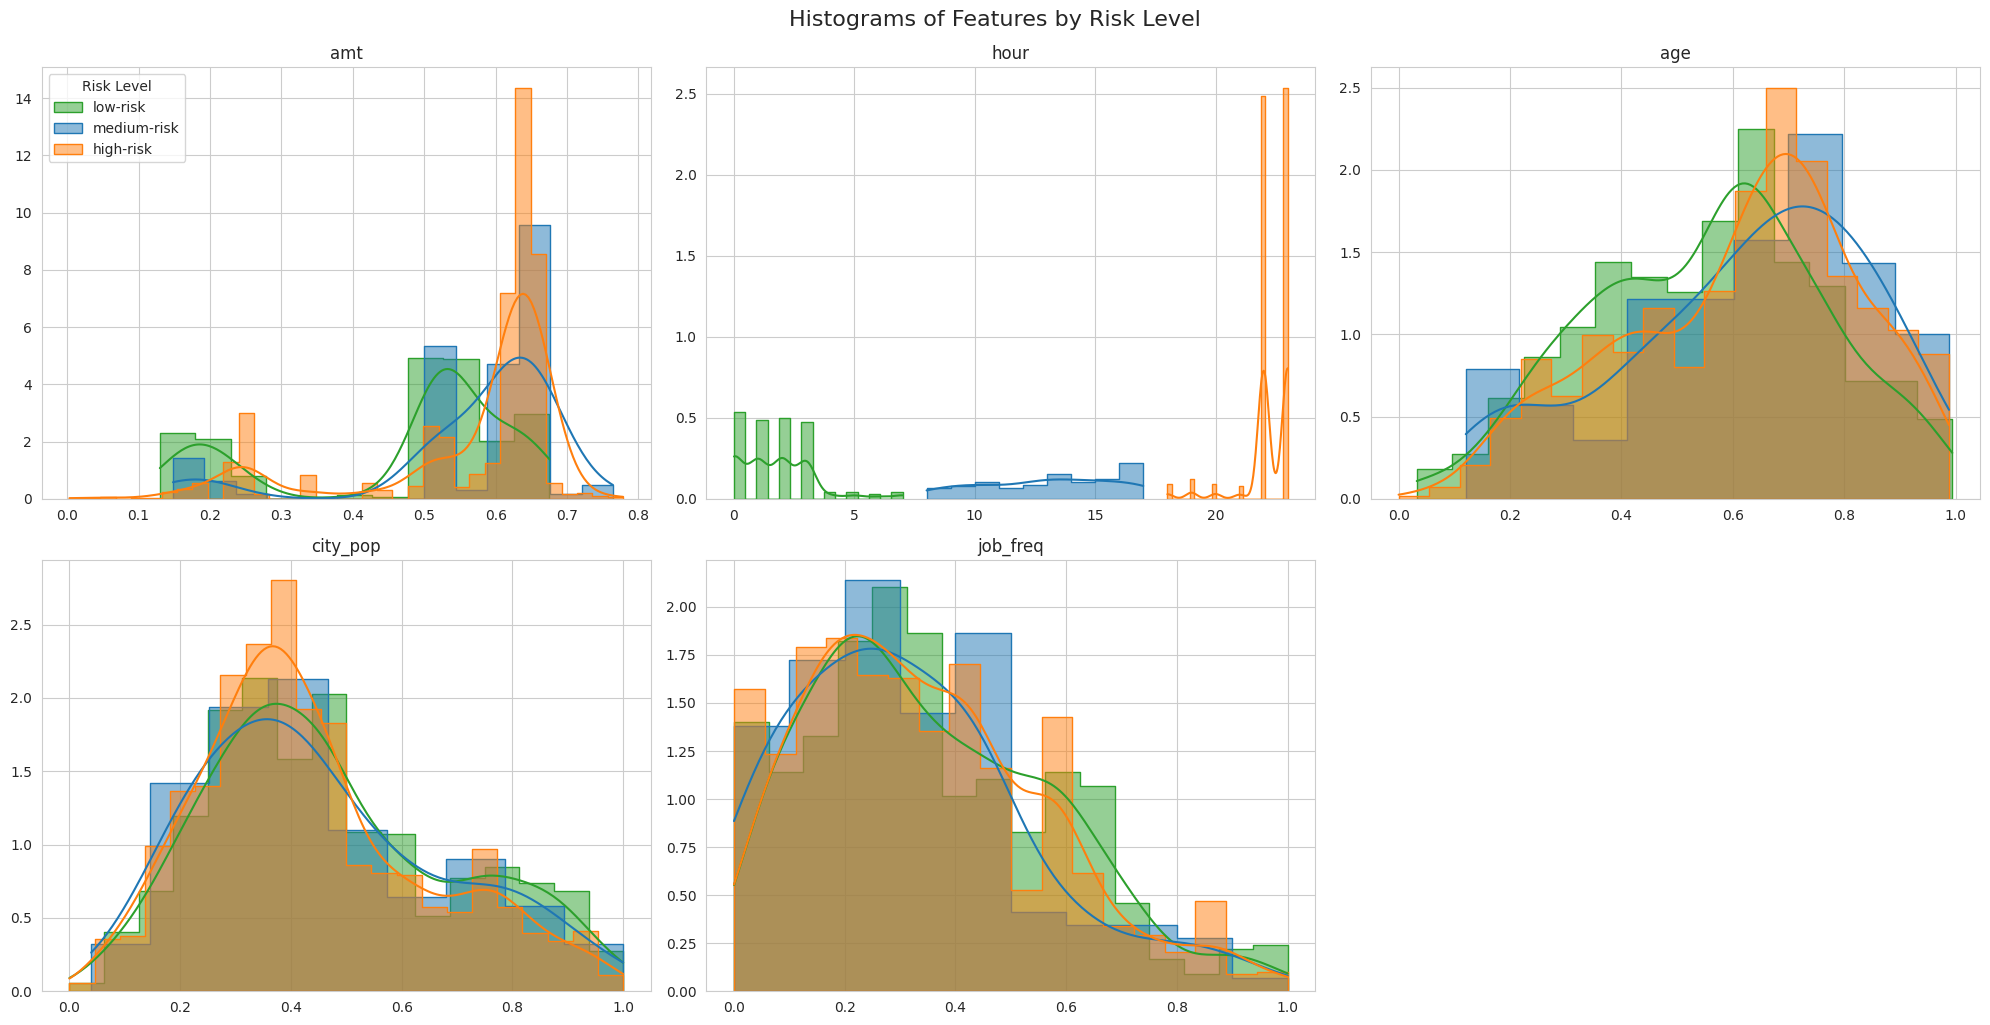

In [ ]:
plt.figure(figsize=(20, 10))

custom_colors = {
    'low-risk': '#2ca02c',
    'medium-risk': '#1f77b4',
    'high-risk': '#ff7f0e'
}

for i, feature in enumerate(risk_features):
  plt.subplot(2, cols, i + 1)

  for risk in risk_categories:
    subset = fraud_data[fraud_data['risk_level'] == risk]
    sns.histplot(subset[feature],
                 kde = True, # Compute kernel density
                 label = risk,
                 stat = 'density', # normalize such that the area = 1
                 element = 'step',
                 common_norm = False,
                 color = custom_colors[risk])


  plt.title(f'{feature}')
  plt.xlabel('')
  plt.ylabel('')

  if i == 0:
    plt.legend(title = 'Risk Level', loc = 'upper left')

plt.tight_layout()
plt.suptitle('Histograms of Features by Risk Level', y = 1.02, fontsize = 16)
plt.show()

In [ ]:
for feature in risk_features:
  groups = [group[feature].values for name, group in fraud_data.groupby('risk_level')]
  f_val, p_val = f_oneway(*groups) # Unpack the list and pass it (required argument)
  print(f'Feature: {feature}, p-value: {p_val:.7f}')

Feature: amt, p-value: 0.0000000
Feature: hour, p-value: 0.0000000
Feature: age, p-value: 0.0000000
Feature: city_pop, p-value: 0.0005932
Feature: job_freq, p-value: 0.0585580


<ipython-input-117-87c802733800>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[feature].values for name, group in fraud_data.groupby('risk_level')]


In [ ]:
print('Post-Hoc Test:')
for feature in risk_features:
  tukey = pairwise_tukeyhsd(endog = fraud_data[feature], groups = fraud_data['risk_level'])
  print(f'\nFeature: {feature}')
  print(tukey.summary())

Post-Hoc Test:

Feature: amt
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
high-risk    low-risk  -0.0971    0.0 -0.1131 -0.0811   True
high-risk medium-risk   0.0067 0.8715 -0.0249  0.0384  False
 low-risk medium-risk   0.1039    0.0  0.0715  0.1362   True
------------------------------------------------------------

Feature: hour
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj  lower    upper   reject
-------------------------------------------------------------
high-risk    low-risk -20.5436   0.0 -20.6878 -20.3994   True
high-risk medium-risk  -9.3304   0.0  -9.6159  -9.0449   True
 low-risk medium-risk  11.2132   0.0  10.9216  11.5049   True
-------------------------------------------------------------

Feature: age
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2 

## 3D Visualization of Clusters

In [ ]:
tsne = TSNE(n_components = 3, perplexity = 125, random_state = seed) # 3 components for 3D mapping
X_tsne_3d = tsne.fit_transform(X_cluster)

fraud_data['tsne_1'] = X_tsne_3d[:, 0]
fraud_data['tsne_2'] = X_tsne_3d[:, 1]
fraud_data['tsne_3'] = X_tsne_3d[:, 2]

In [ ]:
fig = px.scatter_3d(
  fraud_data, # Dataset

  # Coordinates obtained above
  x = 'tsne_1', # t-sne component x
  y = 'tsne_2', # t-sne component y
  z = 'tsne_3', # t-sne component z

  color = 'risk_level', # clusters colors
  title = 'Risk levels Clusters',

  opacity=0.25, # Opacity of colors

  color_discrete_map = { 'low-risk': 'green', 'medium-risk': 'orange', 'high-risk': 'red'}, # Map cluster colors
  hover_data = ['amt', 'hour', 'age'])

fig.update_layout(
  scene = dict(xaxis_title = 'X component', yaxis_title = 'Y component', zaxis_title = 'Z component'),
  legend_title = 'Risk Levels',
  height = 700)

fig.show()